# Transformers

In [1]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset

/home/gg/git_repos/notebooks/transformer/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Project Description & Background

In this project I will go over transformer language models. Specifically I will be explaining the concepts introduced in the paper [Attention Is All You Need](https://arxiv.org/pdf/1706.03762). This is a very important paper has changed a lot in the tech industry. Because of its importance, I waned to learn about transformers and I figured the best way would be to just implement one myself. I had used PyTorch for previous machine learning projects but recently learned about JAX. One of my biggest interests is low resource languages.

I found [this](https://huggingface.co/somosnlp-hackathon-2022/t5-small-spanish-nahuatl) project on huggingface and was inspired to do it myself from scratch. In this project the team trained a transformer model to translate Spanish to Nahuatl and English. [Nahuatl](https://en.wikipedia.org/wiki/Nahuatl) is a indigineous language to Mexico. The reason for including English is explained in depth in the link but essentially because we dont have much data for Spanish to Nahuatl we first teach the model Spanish to English. This way the encoder learns a lot of the patterns of Spanish so when it comes to learn Nahuatl it only has to focus on the decoder. This served as inspiration for my project and in the end I decided to do the same but I would use JAX to do it all from scratch. 


The notebook will cover the architecture which includes encoder, decoder, attention, etc. I will also be covering the math behind it as well as training. I have also implemented my own transformer using Jax. The code for that can be found in the `./src`and `main.py`. Lets get into it! 

## Advantages of Transformer Models

One of the many advantages of transformer models is that they can process large amounts of text data at once. Previously Long Short Term Memory (LSTM) networks/recurrent networks were used to model language but one of their flaws is that they processed data one word (token) at a time. This made it difficult for models to understand text from the beginning of a sequence if the sequence was large, suffered from vanishing gradients, and processed data one token at a time which is computational expensive for large data sets. With the transformer architecture models are capable of better understanding data throughout the sequence and process large amounts of data at once. The specific task discussed in the paper was language translation. Which we will also try to implement. Usually for tasks like text generation like GPT models, only the decoder part of the model is used. Because I want to understand the transformer model thoroughly I want to implement both the encoder and decoder.

## Model Architecture

The transformer architecture from the paper Attention Is All You Need consists of a N decoder and encoder blocks. The encoder block consits of 

### Input Embeddings
The Encoder takes embeddings as input. Embeddings are vectors representations of a word/token. The embeddings are learnable parameters. In the original paper each token embedding is of size $512$ defined as $d_{model}$. Here is an example of some text and what the tokens might look like.  

- **Sequence:**  lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod
tempor incididunt ut labore et dolore magna aliqua.
- **Tokens:**  (lorem ipsum dolor) (sit) (amet, consectetur) (adipiscing elit, sed do) (eiusmod) (tempor) (incididunt) (ut labore) (et dolore magna aliqua.)


- **Sequence:**  Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo
consequat.
- **Tokens:**  (Ut) (enim ad minim veniam,) (quis nostrud) (exercitation) (ullamco) (laboris) (nisi ut aliquip) (ex ea) (commodo consequat.)


Although tokens can be of any size, its easier to understand the attention mechanism if we only think of tokens as one word so in this notebook each token is just one word. Each token is also mapped to a id so that we so we can later look them up in our vocbulary. This is an example of what a token embedding might look like. 

- **Token:**  Dog
- **Token ID:** [12]
- **Embedding:** $\{e_1, e_2, \dots , e_{512} \}$


All together our input embedding is a matrix of size $(\text{seq len}, d_{model})$. This is pretty straight forward. It just means we have a sequence of tokens of size $ \text{seq len} $ and each is represented by a vector of size $d_{model}$.

I used the sentence piece tokenizer to get tokens. Tokens are also learnable but I will not go into detail about them here. You can read more about the sentence piece tokenzier [here](https://github.com/google/sentencepiece).

### Positional Embeddings

Positional embeddings give information about the positon of the token in the sequence. The original paper uses trig for the positional embeddings. In my implementation we use a learnable parameter. 

### Residual Connections
The original paper used residual connections after each attention and linear layer. In my implementation we did it before because the tutorial I followed for implemenation said it was most commonly done this way. The residual connection in the original paper is defined as $LayerNorm(x + SubLayer(x))$. 

Instead we do 
$$
\begin{aligned}
x_{norm} &= LayerNorm(x) \\[4pt]
SubLayerOutput &= SubLayer(x_{norm}) \\[4pt]
x &= x + DropOut(SubLayerOutput)
\end{aligned}
$$

**LayerNorm**

Here we go over a brief of what LayerNorm does. Lets say we have samples with shape `(batch_size=3, seq_len=5, d_model=10)`. We have 3 seqeunces each of size 5 where each token in the sequence has a embedding size of 10. Then what we will do is calculate the mean and variance for each token embedding and normalize it. Lets go over an example.

In [2]:
batch = np.random.rand(3, 5, 10) # Create an array with 3 5x10 arrays

In [3]:
batch.shape

(3, 5, 10)

In [4]:
batch

array([[[0.48738186, 0.40507569, 0.02281243, 0.56541871, 0.98438942,
         0.25522013, 0.87521797, 0.28281012, 0.06977169, 0.21539304],
        [0.29489268, 0.30814375, 0.69892274, 0.73069289, 0.86900051,
         0.70803121, 0.65208362, 0.07598732, 0.79828051, 0.62137659],
        [0.1466296 , 0.88826398, 0.64389519, 0.39851181, 0.4834053 ,
         0.29240013, 0.09133004, 0.77840046, 0.70125321, 0.83121348],
        [0.62162132, 0.33585607, 0.89198009, 0.94520859, 0.83387716,
         0.15525907, 0.33416812, 0.51697384, 0.70108377, 0.64717652],
        [0.15929048, 0.90456529, 0.07556962, 0.12157173, 0.66506012,
         0.83869483, 0.91774684, 0.59739684, 0.27265406, 0.99984644]],

       [[0.74697491, 0.54247833, 0.44084685, 0.30396686, 0.41264234,
         0.72788941, 0.30742117, 0.65099631, 0.04494055, 0.78555733],
        [0.28805901, 0.96589275, 0.87448734, 0.78122552, 0.74141632,
         0.44711441, 0.69960417, 0.54639182, 0.50647036, 0.8819816 ],
        [0.74915566, 0.24

In [5]:
mean = np.mean(batch, axis=-1, keepdims=True) # calculate the mean along the last dimension
variance = np.var(batch, axis=-1, keepdims=True) # calculate the mean along the last dimension

In [6]:
mean # the mean for each token in the sequence for each example

array([[[0.41634911],
        [0.57574118],
        [0.52553032],
        [0.59832046],
        [0.55523962]],

       [[0.49637141],
        [0.67326433],
        [0.50757457],
        [0.4640641 ],
        [0.53704862]],

       [[0.44562538],
        [0.45980382],
        [0.57671374],
        [0.42940202],
        [0.37763993]]])

In [7]:
mean.shape

(3, 5, 1)

In [8]:
variance # the variance for each token in the sequence for each example

array([[[0.09197905],
        [0.06003581],
        [0.07382035],
        [0.06171291],
        [0.12000812]],

       [[0.0512671 ],
        [0.04301229],
        [0.0876911 ],
        [0.07160741],
        [0.08776562]],

       [[0.08058171],
        [0.07797882],
        [0.1328392 ],
        [0.09395132],
        [0.05839529]]])

In [9]:
variance.shape

(3, 5, 1)

In [10]:
batch = (batch - mean)/ np.sqrt(variance) # normalize

In [11]:
batch.shape

(3, 5, 10)

In [12]:
batch

array([[[ 0.23421473, -0.03717158, -1.29759975,  0.4915239 ,
          1.87298673, -0.53128702,  1.51301814, -0.44031515,
         -1.14276203, -0.66260798],
        [-1.14621721, -1.09213607,  0.50273661,  0.63239902,
          1.19686908,  0.53991066,  0.31157373, -2.039628  ,
          0.90824199,  0.18625018],
        [-1.39456052,  1.33505699,  0.43564703, -0.46749714,
         -0.15504297, -0.85804579, -1.59809298,  0.93069952,
          0.64675571,  1.12508012],
        [ 0.09379592, -1.05653127,  1.18210546,  1.39637292,
          0.94821637, -1.78351135, -1.06332598, -0.32745486,
          0.41366626,  0.19666653],
        [-1.14296804,  1.0083822 , -1.38464118, -1.25184901,
          0.31701373,  0.818237  ,  1.04643278,  0.12169329,
         -0.81572664,  1.28342588]],

       [[ 1.10679649,  0.20363237, -0.24522555, -0.84975939,
         -0.36979146,  1.02250493, -0.83450334,  0.68290466,
         -1.99375542,  1.27719672],
        [-1.85735964,  1.41097797,  0.97024488,  0

### Encoder

Lets get into the encoder. Both the encoder and decoder part of the model usually contains multiple layers. In our case we have 6 blocks of the encoder and 6 blocks of the decoder. This means we repeat the encoder 6 or N times. Here is an image of the architecture from the paper. The encoder is responsible for getting information about the input sequence. In our case the encoder is responsible for learning the patterns of the Spanish language (source language) and how all tokens interact with one another. This information is later passed to the decoder so we can use this information to translate the source sequence into the target sequence. 


![title](images/encoder.png)

As mentioed earlier we have a slightly different a architecture. Our architecure follows this.

$$
\begin{aligned}
x_{\text{norm}} &= \operatorname{LayerNorm}(x), \\[4pt]
\text{MultiHeadAttentionBlockOutput} &= \operatorname{MultiHeadAttentionBlock} 
        \left(
       q=x_{\text{norm}},
       k=x_{\text{norm}},
       v=x_{\text{norm}}
       \right), \\[4pt]
x &= x + \operatorname{Dropout}
     \left(\text{MultiHeadAttentionBlockOutput}\right), \\[8pt]
x_{\text{norm}} &= \operatorname{LayerNorm}(x), \\[4pt]
\text{FeedForwardBlockOutput}
    &= \operatorname{FeedForwardBlock}(x_{\text{norm}}), \\[4pt]
x &= x + \operatorname{Dropout}
     \left(\text{FeedForwardBlockOutput}\right).
\end{aligned}
$$
The final output is then passed into the decoder.

### Decoder
The encoder architecture is very similar. In the paper it is defined as this image below. The encoder is responsible for 

![title](images/decoder.png)

Our implementation is slightly different too. Here is our architecture. 
$$
\begin{aligned}
x_{\text{norm}} &= \operatorname{LayerNorm}(x), \\[4pt]
\text{MaskedMultiHeadAttentionBlockOutput} &= \operatorname{MaskedMultiHeadAttentionBlock} 
        \left(
       q=x_{\text{norm}},
       k=x_{\text{norm}},
       v=x_{\text{norm}}
       \right), \\[4pt]
x &= x + \operatorname{Dropout}
     \left(\text{MaskedMultiHeadAttentionBlockOutput}\right), \\[8pt]
x_{\text{norm}} &= \operatorname{LayerNorm}(x), \\[4pt]
\text{CrossMultiHeadAttentionBlockOutput} &= \operatorname{CrossMultiHeadAttentionBlock} 
        \left(
       q=x_{\text{norm}},
       k={\text{encoder\_output}},
       v={\text{encoder\_output}}
       \right), \\[4pt]
x &= x + \operatorname{Dropout}
     \left(\text{CrossMultiHeadAttentionBlockOutput}\right), \\[8pt]
x_{\text{norm}} &= \operatorname{LayerNorm}(x), \\[4pt]
\text{FeedForwardBlockOutput}
    &= \operatorname{FeedForwardBlock}(x_{\text{norm}}), \\[4pt]
x &= x + \operatorname{Dropout}
     \left(\text{FeedForwardBlockOutput}\right).
\end{aligned}
$$

Weve covered residual connections, layer norm, input and positional embeddings. Now lets go over attention. 

#### Attention
Attention is defined as.  
$$ Attention(Q, K, V) = softmax(\frac{QK^{T}}{\sqrt{d_k}})V $$

This equation may look very confusing so lets break it down part by part. 

We have a input embeddings of size (${seq\_len}$, $d_{model}$). For a basic visual example lets say "The dog ate" is our input. Then we would have a matrix of shape (${seq\_len}$, $d_{model}$) but only the first 3 rows are used for the embeddings of our sequence "The dog ate". 

Here are our defined parameters ${seq\_len}=5$, $d_{model}=10$, $h heads = 5$ and $d_k=\frac{d_{model}}{h heads} = \frac{10}{5} = 2$ 

If we remeber back to this diagram we see that we pass the input 3 times. This is Q, K, V. So lets begin

In [13]:
q = np.matrix([
    [8 , 63 , 39 , 36 , 81 , 3 , 73 , 8 , 50 , 2],
    [61 , 90 , 99 , 92 , 42 , 25 ,  30 , 5 , 4, 79],
    [11 ,  99 , 10 , 34 , 72 , 9 , 74 , 84 , 65 , 62],
    [0 , 0 , 0 , 0 , 0 , 0 , 0 , 0 , 0 , 0],
    [0 , 0 , 0 , 0 , 0 , 0 , 0 , 0 , 0, 0],
]) # this is a random matrix that I made up, it doesnt mean anything

In [14]:
k = v = q # q, k, v = x/input

In [15]:
k_t = k.T # K Transpose

Confirming the shapes of our matricies

In [16]:
q.shape

(5, 10)

In [17]:
k_t.shape

(10, 5)

In [18]:
v.shape

(5, 10)

Now lets do the first step which is 
$QK^{T}$

In [19]:
qk_t = q @ k_t

Lets check the shape of this and the actual values.

In [20]:
qk_t.shape

(5, 5)

In [21]:
qk_t

matrix([[21317, 19396, 23246,     0,     0],
        [19396, 39657, 24746,     0,     0],
        [23246, 24746, 37044,     0,     0],
        [    0,     0,     0,     0,     0],
        [    0,     0,     0,     0,     0]])

Now we are going to do this part $\frac{QK^{T}}{\sqrt{d_k}}$ in the equation.

In [22]:
seq_len, d_model = q.shape

In [23]:
heads = 5

In [24]:
d_k = d_model/heads

In [25]:
qk_t_dk = qk_t / (d_model ** 1/2)

In [26]:
qk_t_dk.shape

(5, 5)

In [27]:
qk_t_dk

matrix([[4263.4, 3879.2, 4649.2,    0. ,    0. ],
        [3879.2, 7931.4, 4949.2,    0. ,    0. ],
        [4649.2, 4949.2, 7408.8,    0. ,    0. ],
        [   0. ,    0. ,    0. ,    0. ,    0. ],
        [   0. ,    0. ,    0. ,    0. ,    0. ]])

Now we are going to apply softmax to $\frac{QK^{T}}{\sqrt{d_k}}$ which will give us $softmax (\frac{QK^{T}}{\sqrt{d_k}})$. Softmax is $\frac{e^{z_i}}{\sum^N_{j=1} e^{z_j} }$

In [28]:
numerator = np.exp(qk_t_dk- np.max(qk_t_dk, axis=-1))
softmax = numerator / np.sum(numerator, axis=-1)

In [29]:
softmax.shape

(5, 5)

In [30]:
softmax

matrix([[2.81312404e-168, 0.00000000e+000, 1.00000000e+000,
         0.00000000e+000, 0.00000000e+000],
        [0.00000000e+000, 1.00000000e+000, 0.00000000e+000,
         0.00000000e+000, 0.00000000e+000],
        [0.00000000e+000, 0.00000000e+000, 1.00000000e+000,
         0.00000000e+000, 0.00000000e+000],
        [2.00000000e-001, 2.00000000e-001, 2.00000000e-001,
         2.00000000e-001, 2.00000000e-001],
        [2.00000000e-001, 2.00000000e-001, 2.00000000e-001,
         2.00000000e-001, 2.00000000e-001]])

Alright we have applied softmax now all that is left to finish computing attention is multplying $softmax (\frac{QK^{T}}{\sqrt{d_k}})$ by $V$. 

In [31]:
softmax_v  = softmax @ v

In [32]:
softmax_v.shape

(5, 10)

In [33]:
softmax_v

matrix([[11. , 99. , 10. , 34. , 72. ,  9. , 74. , 84. , 65. , 62. ],
        [61. , 90. , 99. , 92. , 42. , 25. , 30. ,  5. ,  4. , 79. ],
        [11. , 99. , 10. , 34. , 72. ,  9. , 74. , 84. , 65. , 62. ],
        [16. , 50.4, 29.6, 32.4, 39. ,  7.4, 35.4, 19.4, 23.8, 28.6],
        [16. , 50.4, 29.6, 32.4, 39. ,  7.4, 35.4, 19.4, 23.8, 28.6]])

We have now computed our attention scores! 

Now that was regular self attention which is where we process the matrix all at once. Now lets get into multi head attention which is what transformers use.

#### Multi Head Attention
Multi head attention (MHA) is very very similar but instead of calculating attention all at once we split the matrix in `h` heads. We defined a variable of $\text{h heads} = 5$ above. 

The idea with MHA is that we calcualte attention for each head. This way each head contains a small part of each query key and value and each head can .... The once we have the attention scores computed for each of the heads we combine them back to get the attention matrix. 

So we still have our matrix from before which is. 

In [34]:
q

matrix([[ 8, 63, 39, 36, 81,  3, 73,  8, 50,  2],
        [61, 90, 99, 92, 42, 25, 30,  5,  4, 79],
        [11, 99, 10, 34, 72,  9, 74, 84, 65, 62],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

Now we are going to split uour matrix q into h heads. 

In [35]:
q_heads = np.asarray(q).reshape(seq_len, heads, int(d_k)).transpose(1, 0, 2)

This gives us our Q matrix split into heads as 

In [36]:
q_heads.shape

(5, 5, 2)

In [37]:
q_heads

array([[[ 8, 63],
        [61, 90],
        [11, 99],
        [ 0,  0],
        [ 0,  0]],

       [[39, 36],
        [99, 92],
        [10, 34],
        [ 0,  0],
        [ 0,  0]],

       [[81,  3],
        [42, 25],
        [72,  9],
        [ 0,  0],
        [ 0,  0]],

       [[73,  8],
        [30,  5],
        [74, 84],
        [ 0,  0],
        [ 0,  0]],

       [[50,  2],
        [ 4, 79],
        [65, 62],
        [ 0,  0],
        [ 0,  0]]])

We do this for $K^T$ and $V$ and basically do the same as we did above but for every head. I will not do it here tho but you can view the code for this in `./transformer/MultiHeadAttention.py`. Then in the end we concat and multiply by a matrix $W^O$. As mentioned the reason for this is because now each head sees the full sequence but a small part of its embedding, meaning each head can get unique information from the sequence. 

In the end this is our equation. 

$$ \forall i \in \text{h heads} \hspace{10px} head_i =  AttentionHead(Q_i,K_i, V_i) = softmax(\frac{Q_iK^{T}_i}{\sqrt{d_k}})V_i $$

$$ Attention(Q,K,V) = concat_{n=1}^{\text{h heads}}(head_i)W^{O}$$

### Projection Layer

### Recap
To fully understand what weve done lets go through the shape change for a input. We are going to assume only 1 sample for simplicity. 

#### Encoder Inputs
We get our inputs for our encoder which gives us shape $(seq \_ len, d_{model})$

#### Positional Encoding
We then get information on the positions we keep our shape of $(seq \_ len, d_{model})$

#### Encoder Blocks
- We apply layer norm which is so we keep our $(seq \_ len, d_{model})$
- After that we pass to our attention block. The input x gets duplicated into q,k,v.
- Each q,k,v is size $(seq \_ len, d_{model})$ and goes through a linear layer of shape $(d_{model}, d_{model})$ so our shape stays at $(seq \_ len, d_{model})$
- We then reshape this from $(seq \_ len, d_{model})$ into $(n\_heads, seq\_len, d_k)$ where $d_k = \frac{d_{model}}{n_{heads}}$. This is so we can perform attention on each head.

## Training & Architecture 
As mentioned in the beggining, we are training the model to learn Spanish to English and Nahuatl. There was two approaches to this. One approach is to mix the Spanish to English Dataset of size `157895` with the Spanish to Nahuatl which is of size `20028`. I feared that taking this approach would cause the model to ovefit on the Spanish to English because of the big data imbalance. This would probably produce good results but the task is to translate Nahuatl and I wanted to prioritize that.

The second approach is have two phases. Phase one we teach the Spanish and English first. Then we teach Spanish to Nahuatl. This would make it so that we prioritized only Nahuatl but would cause is to potentially lose performance on English. However because the task is to learn Nahuatl I decided it was a good trade off. So that is what I did. 


I am trained on my own personal machine using my 3070. In the original paper they set a `seq_len` of `128` but because of memory issues I had to set `seq_len` to. I could have used a smaller model by lowering `N`, `H`, `SEQ_LEN`, `D_MODEL` or `D_FF` but I did not want to sacrifice performance.


Lowering the `seq_len` to `128` introduce us to another issue. In linguistics we learn about the issue of data sparsity. Meaning that in a corpus (dataset) there is a small amount of words that appear lots of times and lots of words that appear a very small amount. I belive each sample in the Spanish Nahuatl dataset was 200 plus tokens which meant that on top of it already be a small dataset we see even less of the data because if sequence length cuts off samples. 

We learn also about [Zipfs law](https://en.wikipedia.org/wiki/Zipf%27s_law) which can help us demonstrate this. The idea is that given a ordered list of word frequencies the frequency of a word at some rank is roughly $C/rank$ where rank is the index that word is in the order. 

Lets demonstrate the data sparsity issue.

In [38]:
with open("./data/TED2013.en-es.es", "r", encoding="utf-8") as f:
    es = [line.strip() for line in f]

In [39]:
with open("./data/TED2013.en-es.en", "r", encoding="utf-8") as f:
    en = [line.strip() for line in f]

In [40]:
len(en)

157895

In [41]:
dataset = load_dataset("somosnlp-hackathon-2022/Axolotl-Spanish-Nahuatl")

In [42]:
es_two = list(dataset["train"]["sp"])
nah = list(dataset["train"]["nah"])

In [43]:
len(nah)

20028

In [44]:
print(f"ES TYPE: {type(es)} ES_TWO TYPE: {type(es_two)}  ")

ES TYPE: <class 'list'> ES_TWO TYPE: <class 'list'>  


In [45]:
es = es + es_two # combine spanish

In [46]:
def get_frequencies(lang: list) -> dict:
    frequencies = {}
    for i in range(len(lang)):
        sentence = lang[i].lower().split() if lang[i] else None
        if sentence:
            for j in range(len(sentence)): 
                word = sentence[j].lower()
                if word in frequencies:
                    frequencies[word] += 1
                else: 
                    frequencies [word] = 1
        else:
            continue

    return frequencies

In [47]:
def to_df(frequencies: dict) -> pd.DataFrame:
    frequencies_df = pd.DataFrame(frequencies.items(), columns=["word", "frequency"])
    frequencies_df = frequencies_df.sort_values("frequency", ascending=False)
    return frequencies_df

In [48]:
es_frequencies = get_frequencies(es)
en_frequencies = get_frequencies(en)
nah_frequencies = get_frequencies(nah)

In [49]:
es_df = to_df(es_frequencies)
en_df = to_df(en_frequencies)
nah_df = to_df(nah_frequencies)

In [50]:
print(f"Spanish: {es_df.info()}\nEnglish: {en_df.info()}\nNahuatl: {nah_df.info()}")

<class 'pandas.DataFrame'>
Index: 172292 entries, 22 to 172252
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   word       172292 non-null  str  
 1   frequency  172292 non-null  int64
dtypes: int64(1), str(1)
memory usage: 5.6 MB
<class 'pandas.DataFrame'>
Index: 104954 entries, 8 to 104942
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   word       104954 non-null  str  
 1   frequency  104954 non-null  int64
dtypes: int64(1), str(1)
memory usage: 3.3 MB
<class 'pandas.DataFrame'>
Index: 72545 entries, 21 to 72541
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   word       72545 non-null  str  
 1   frequency  72545 non-null  int64
dtypes: int64(1), str(1)
memory usage: 2.5 MB
Spanish: None
English: None
Nahuatl: None


In [51]:
es_df.head()

,word,frequency
22,de,153357
59,que,110724
4,y,97030
10,la,89506
28,en,79632


In [52]:
en_df.head()

,word,frequency
8,the,126842
4,and,89732
79,to,73688
23,of,69646
2,a,64088


In [53]:
nah_df.head()

,word,frequency
21,yn,16481
1,in,13841
4,on,13485
6,niman,8769
48750,yejhuan,5667


In [54]:
def plot(x, y, title: str):
    plt.figure(figsize=(12,6))
    plt.bar(x,y) 
    plt.xlabel('Token')
    plt.ylabel('Count')
    plt.xticks(rotation=45)  
    plt.title(title)
    plt.show()

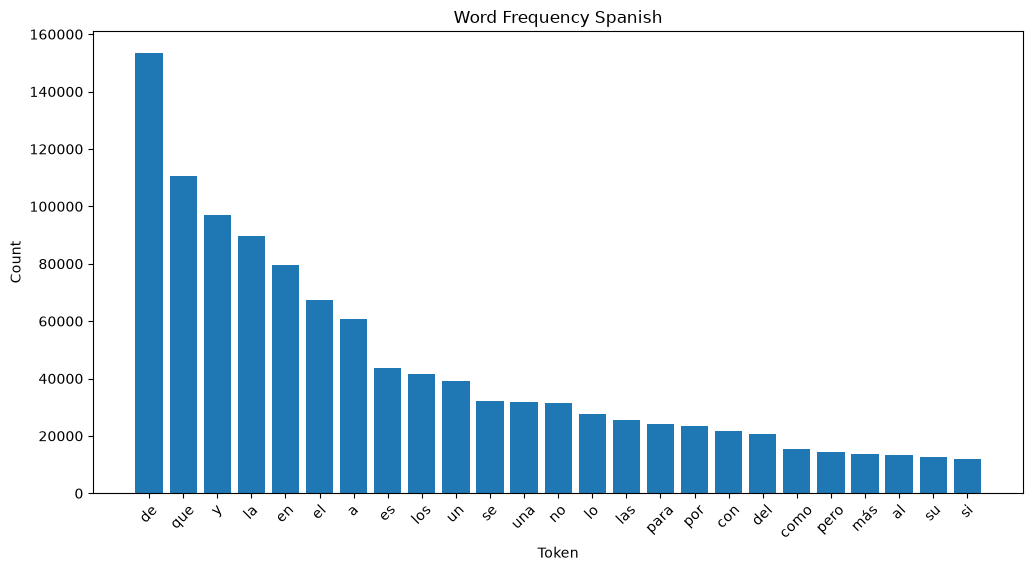

In [55]:
plot(es_df.word[:25], es_df.frequency[:25], "Word Frequency Spanish")

Above we have the word frequencies for our Spanish corpus. We previously saw that we have `172292` entries. Of these entries there are like 7 words that appear a lot. The words are `de`, `que`, `y` `la`, `en`, `el`, and `a`. As the rank increases the frequency decreases. The words we see here are the ones we should expect to see in the english corpus as well. They translate to `of/from`, `that`, `and`, `the`, `in`, `the` and `to`. This does not prove Zipfs law but rather just shows the issue of data sparsity. We have very few words that are very frequent but are not useful for our model to learn the language. While the rest of the words in the corpus rarely appear. 

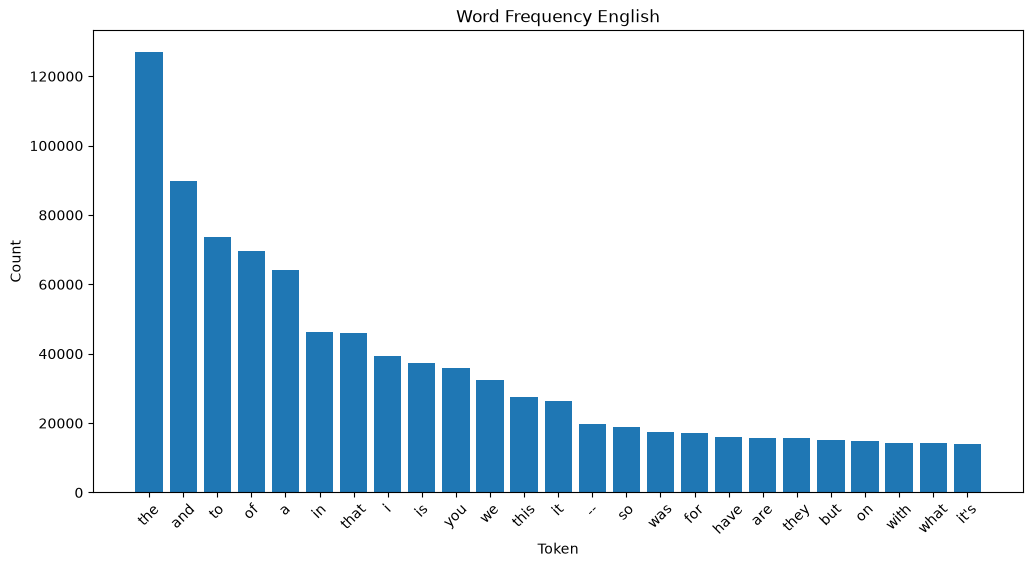

In [56]:
plot(en_df.word[:25], en_df.frequency[:25], "Word Frequency English")

In our english corpus we have `104954` entries. Again there are very vew words that appear a lot of times. We can also see that the words match the ones in Spanish. Not all but a good amount of them.

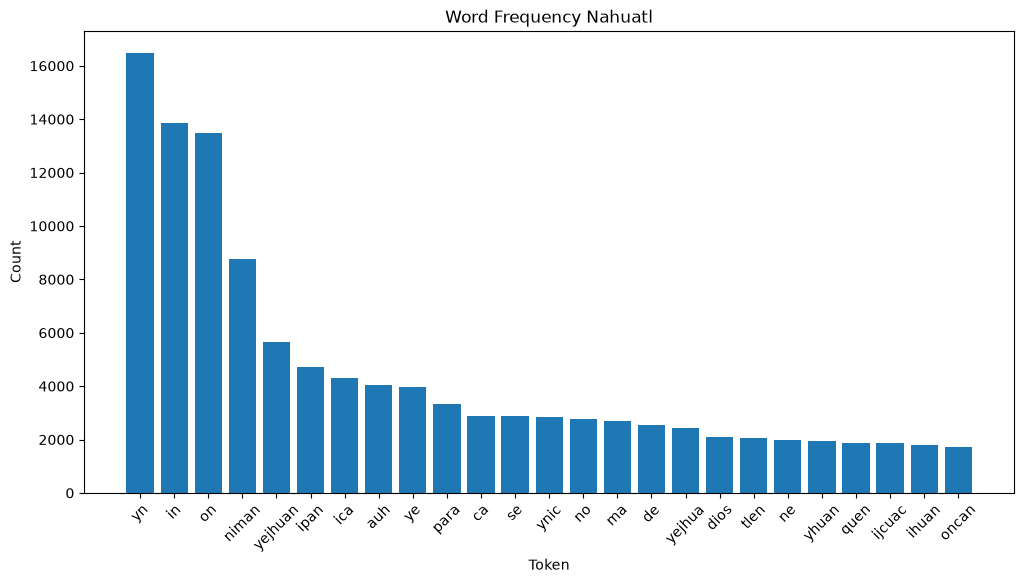

In [57]:
plot(nah_df.word[:25], nah_df.frequency[:25], "Word Frequency Nahuatl")

Lastly we arrive to Nahuatl. We have `72545` entries. There are even fewer words that appear a lot of times. The words are `yn`, `in`, `on` and `niman`. `in` translates to `estas/estos` in Spanish which means `these` or `those` in English ([source](https://gdn.iib.unam.mx/diccionario/in)). `on` translates to `that` ([source](https://gdn.iib.unam.mx/diccionario/on)). `Niman` roughly translates to `later` ([source](https://gdn.iib.unam.mx/diccionario/niman)). These are words we expect to see frequently used. Again this does not prove zipfs law it just goes to show that data sparsity is a big issue. 

Alright so all this to say that we already have very little data, and the data/words we want our model to be exposed to in order learn properly are not frequent. Now back to the point of cutting down our `seq_len` from `350` to `128`. This means that the data sparsity issue is an even bigger problem here. A next step after this project would be to train a smaller model but has the `350` sequence length so it can see all the available data. 

### Phase 1
So for phase 1 we have our Spanish to English dataset which was `157895` samples. Below are the hyper parameters I choose for the model.

```
BATCH_SIZE=32,
EPOCHS=50,
LR=3e-4,
SEQ_LEN=128,
D_MODEL=512,
D_FF=2048,
H=8,
N=6,
DROPOUT_SCHEDULE={0: 0.15, 15: 0.25, 30: 0.3},
WEIGHT_DECAY=0.05

```

Initially the model was overfitting by a lot so I chose a dropout rate schedule. The idea is that the first few iterations have minimal dropout so the model can learn as much as possible quickly. At around iteration 15 it starts to overfit so we introduce a higher level of dropout so that the model can truly learn. To further prevent overfitting at around iteration 30 we update the dropout to be higher. This way we ensure that the model learns and does not overfit in the final iterations. The epochs was set about 100 but I really only ran it 50. I continued the training and got a better eval loss at around 70 but its really is not much improvement. This took like about 10 hours if i remember correctly. At epoch 70 we got the best performance with these values.
```
{
    train_loss: 2.083785057067871,
    eval_loss: 2.5277516841888428,
    eval_accuracy: 0.7249569892883301
}
```

## Phase 2
For phase two we had a lot less data. The dataset is of size `20028` but on top of this I added in a `%` Spanish to English samples. The reason for this was to balance it out and keep some of the english knowledge but also doing this helped with performance. Adding Spanish to English pairs helped because when we had zero the model did not perform well. I am not entirely sure why because for the second phase I did not evaluate on Spanish to English pairs.  When training we used the best checkpoint from phase 1 which was `70`. I did several runs.

The most importatnt are at `metrics/chckpnts_phase_2_mixed_model_bsize_12_epoch_200.csv`, `metrics/phase_two_200_schedule_b12_weight_decay_0_05_pt11` and `phase_two_no_transfer`. 

For some reason I was not able to replicate the results of `metrics/chckpnts_phase_2_mixed_model_bsize_12_epoch_200.csv`. I also did not save any metadata containing hyper paramters so this made it even more diffucult to try and attempt to recreate the results. The reason for wanting to replicate this run was because it had the best peformance of any future runs and it was very early on. Other models got close but it was later on.

`metrics/phase_two_200_schedule_b12_weight_decay_0_05_pt11` uses the Spanish English checkpoint that performed best so that we could use the Spanish knowledge to help us focus on learning Nahuatl. `phase_two_no_transfer` starts from scratch, no checkpoint and no Spanish English samples included just the data. The point is to see if pretraining a Spanish English model would help in the task of learning Nahuatl. 

Lets see the results and compare.

## Results 

In [58]:
lost_run = pd.read_csv("./metrics/chckpnts_phase_2_mixed_model_bsize_12_epoch_200.csv")

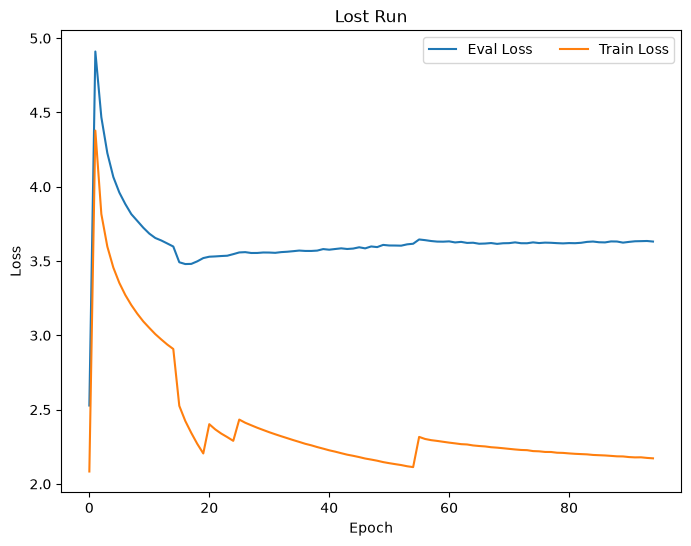

In [72]:
plt.figure(figsize=(8,6))
plt.plot(lost_run.epoch, lost_run.eval_loss, label="Eval Loss") 
plt.plot(lost_run.epoch, lost_run.train_loss, label="Train Loss") 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right', ncols=10)
plt.title("Lost Run")
plt.show()

As mentioned we use checkpoint 70 from phase 1 as the start for this training run. The hyper parameters for this run were this.
```
{
    "epoch": 200,
    "stop": "none",
    "batch_size": 12,
    "start_lr": 0.0001,
    "dropout_schedule": "0: 0, 15: 0.1, 20: 0.2, 25: 0.25, 45: 0.25, 55: 0.3"?,
    "weight_decay": 0.05
    "data_split": 0.4?
}
```
I could be wrong because I dont remeber using this dropout rate schedule and as you can see they kinda dont really match with the spikes in the training loss. I used this small batch size because since our dataset is so small it helped the model generalise better. This was used for future runs as well. I dont remeber the exact split we used for adding Spanish English samples but I belive it was 40% split. I am more confident on this than the dropout rate schedule. At epoch 17 we had the best performance with these values. 

```
{
    "train_loss": 2.343492031097412,
    "eval_loss": 3.481031656265259,
    "eval_accuracy": 0.47917136549949646
}
```

Moving on to the next run.

In [60]:
run_eleven = pd.read_csv("./metrics/phase_two_200_schedule_b12_weight_decay_0_05_pt11.csv")

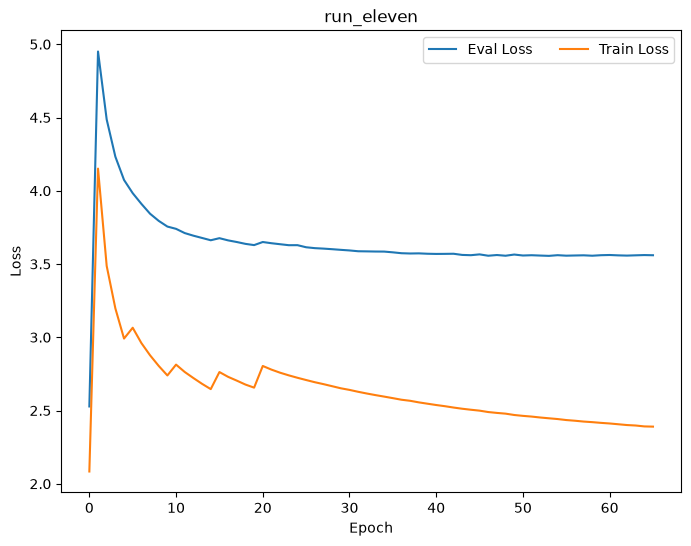

In [75]:
plt.figure(figsize=(8,6))
plt.plot(run_eleven.epoch, run_eleven.eval_loss, label="Eval Loss") 
plt.plot(run_eleven.epoch, run_eleven.train_loss, label="Train Loss") 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right', ncols=10)
plt.title("run_eleven")
plt.show()

The hyper parameters for this run were 
```
{
  "epoch": 200,
  "batch_size": 12,
  "start_lr": 0,
  "peak_lr": 5e-5,
  "dropout_schedule": "0: 0, 5: 0.1, 10: 0.15, 15: 0.20, 20: 0.25",
  "weight_decay": 0.05,
  "save_best_checkpoint_by": "eval_loss",
  "data_split": 0.5
}
```
We can see the jumps at go in hand with the drop out schedule. This run was as close as I got to the previous lost run. There are other runs I have saved in the metrics and chckpnts folders but they are very similar and not worth repeating. You can check them out in the `metrics` folder. The biggest thing 

In [ ]:
no_transfer = pd.read_csv("./metrics/phase_two_no_transfer.csv")

In [76]:
plt.figure(figsize=(8,6))
plt.plot(no_transfer.epoch, no_transfer.eval_loss, label="Eval Loss") 
plt.plot(no_transfer.epoch, no_transfer.train_loss, label="Train Loss") 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right', ncols=10)
plt.title("run_eleven")
plt.show()

NameError: name 'no_transfer' is not defined

<Figure size 800x600 with 0 Axes>

The hyper parameters for this run were 
```
{
  "epoch": 200,
  "batch_size": 12,
  "start_lr": 0,
  "peak_lr": 5e-5,
  "dropout_schedule": "0: 0, 5: 0.1, 10: 0.15, 15: 0.20, 20: 0.25",
  "weight_decay": 0.05,
  "save_best_checkpoint_by": "eval_loss",
  "data_split": 0
}
```
We used no checkpoint and used no Spanish English samples just the Nahuatl Spanish dataset that was given. 

NameError: name 'no_transfer' is not defined

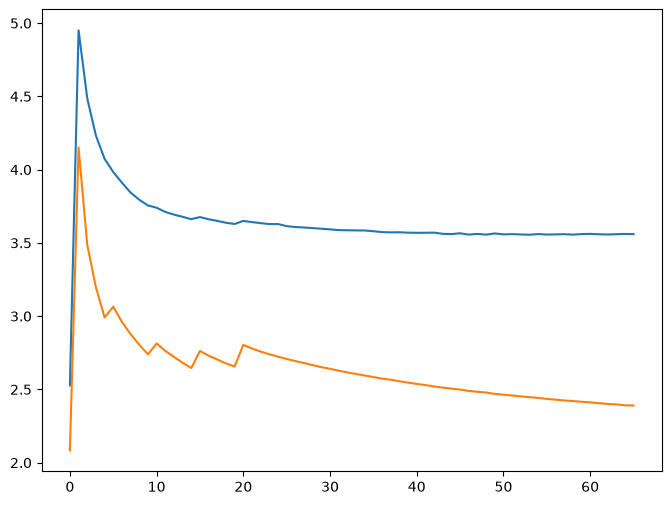

In [78]:
plt.figure(figsize=(8,6))
plt.plot(run_eleven.epoch, run_eleven.eval_loss, label="Eval Loss") 
plt.plot(run_eleven.epoch, run_eleven.train_loss, label="Train Loss") 
plt.plot(no_transfer.epoch, no_transfer.eval_loss, label="No Transfer Eval Loss") 
plt.plot(no_transfer.epoch, no_transfer.train_loss, label="No Transfer Train Loss") 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right', ncols=10)
plt.title("Transfer vs No Transfer")
plt.show()

## Conclusion

Alright so this project was a lot of fun. I really enjoyed learning Jax and Transformers. 

### Useful Resources
Here are some resources that helped me in completing this project.
- https://huggingface.co/datasets/somosnlp-hackathon-2022/Axolotl-Spanish-Nahuatl
- https://docs.jax.dev/en/latest/notebooks/thinking_in_jax.html
- https://wandb.ai/jax-series/simple-training-loop/reports/Writing-a-Training-Loop-in-JAX-and-Flax--VmlldzoyMzA4ODEy
- https://flax.readthedocs.io/en/v0.8.3/experimental/nnx/index.html
- https://youtube.com/playlist?list=PLOU2XLYxmsIJBcjiFi8LdyY5YGR8sz0ZZ&si